# **Algorithm : RBF Kernel SVM**
## **Project : Face Recognition System**
### **Problem Statement :
- Identify individuals using complex facial feature patterns.
- Dataset Format : face_dataset/Person_1, Person_2, ...**

In [36]:
# Step No 1 : Import Required Libraries 

# Import Numerical Library 
import numpy as np 

# Import Pandas Library 
import pandas as pd 

# Import matplotlib library 
import matplotlib.pyplot as plt 

# Import seaborn library 
import seaborn as sns 

# Import operating system library 
import os 

# Import image processing library 
from PIL import Image

# Import train test split 
from sklearn.model_selection import train_test_split

# Import Standard Scaler 
from sklearn.preprocessing import StandardScaler

# Import RBF Kernel SVM
from sklearn.svm import SVC

# Import evaluation metrics 
from sklearn.metrics import(
    accuracy_score , 
    classification_report ,
    confusion_matrix
)

In [37]:
# Step No 2 : Load Dataset Folder 
# Define dataset folder path
dataset_path = "Face_Recognition_RBF_SVM_Dataset"

In [38]:
# Step No 3 : Create Empty Lists 
# Store image features 
X = []

# Store person labels 
y = []



In [39]:
# Step No 4 : Read Person Folders

# Read every folder inside face_dataset
for person_name in os.listdir(dataset_path):

    # Create complete person folder path
    person_path = os.path.join(
        dataset_path,
        person_name
    )

    # Check whether the path is a folder
    if os.path.isdir(person_path):

        # Read every image inside person folder
        for image_name in os.listdir(person_path):

            # Create complete image path
            image_path = os.path.join(
                person_path,
                image_name
            )

            try:

                # Open image
                image = Image.open(
                    image_path
                )

                # Convert image into grayscale
                image = image.convert(
                    "L"
                )

                # Resize image to 64 X 64
                image = image.resize(
                    (64, 64)
                )

                # Convert image into NumPy array
                image_array = np.array(
                    image
                )

                # Normalize pixel values between 0 and 1
                image_array = image_array / 255.0

                # Flatten image into one-dimensional vector
                image_array = image_array.flatten()

                # Add image features
                X.append(
                    image_array
                )

                # Add person name as target label
                y.append(
                    person_name
                )

            except Exception as e:

                # Display image loading error
                print(
                    "Error loading:",
                    image_path,
                    e
                )

In [40]:
# Step No 5 : Convert Lists into Numpy arrays 

# Convert feature list into NumPy array 
X = np.array(X)

# Convert target list into NumPy array
y = np.array(y)

In [41]:
# Step No 6 : Data Understanding 

# Display feature shape 
print("\nFeature Shape : ")
print(X.shape)

# Display target shape 
print("\nTarget Shape : ")
print(y.shape)

# Display unique persons 
print("\nPersons : ")
print(np.unique(y))

# Display number of persons 
print("\nNumber of Persons : ")
print(len(np.unique(y)))

# Display number of images 
print("\nNumber of Images : ")
print(len(X))


Feature Shape : 
(499, 4096)

Target Shape : 
(499,)

Persons : 
['Person_01' 'Person_02' 'Person_03' 'Person_04' 'Person_05']

Number of Persons : 
5

Number of Images : 
499


In [42]:
# Step No 7 : Check Dataset 
# Check whether dataset contains images 
if len(X) == 0 :
    raise ValueError(
        "No images found. Check your face_dataset path."
    )
    
# Check whether there are enough classes 
if len(np.unique(y)) < 2 :
    raise ValueError(
        "At least two persons are required."
    )

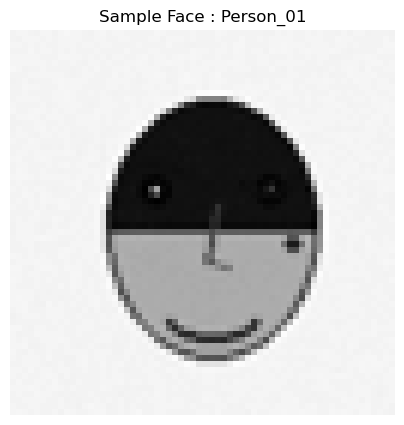

In [43]:
# Step No 8 : Display Sample Face 

# Display first face 
plt.figure(
    figsize=(5 ,5)
)

# Reshape flattened image back to 64 X 64 
sample_image = X[0].reshape(
    64,
    64
)

# Display image 
plt.imshow(
    sample_image,
    cmap="grey"
)

# Display person name 
plt.title(
    "Sample Face : " + y[0]
)

# Remove axis 
plt.axis("off")

# Display plot 
plt.show()

In [44]:
# Step No 9 : Train - Test Split 

# Split dataset into training and testing data 
X_train , X_test , y_train , y_test = train_test_split(
    X ,
    y,
    test_size=0.20,
    random_state=42,
    stratify = y
)

# Display training samples 
print("\nTraining Samples : ")
print(len(X_train))

# Display testing samples 
print("\nTesting Samples : ")
print(len(X_test))


Training Samples : 
399

Testing Samples : 
100


In [45]:
# Step no 10 : Features Scaling 

# Create StandardScaler Object 
scaler = StandardScaler()

# Fit scaler on training data 
# and transform training data 
X_train_scaled = scaler.fit_transform(
    X_train
)

# Transform testing data 
# using the same fitted scaler 
X_test_scaled = scaler.transform(
    X_test
)

In [46]:
# Step No 11 : Create RBF Kernel SVM

# Create SVM model 
# Using RBF Kernel 
model = SVC(
    kernel="rbf",
    C = 10,
    gamma="scale"
)

# Display model 
print("\nRBF Kernel SVM Model : ")
print(model )


RBF Kernel SVM Model : 
SVC(C=10)


In [47]:
# Step No 12 : Train Model 
# Train RBF SVM model 
model.fit(
    X_train_scaled,
    y_train
)

# Display training message 
print(
    "\nModel Training Completed."
)


Model Training Completed.


In [48]:
# Step No 13 : Prediction 
# Predict persons from test images 
y_pred = model.predict(
    X_test_scaled
)

# Display predicted values 
print("\nPredicted Values : ")
print(y_pred)


Predicted Values : 
['Person_03' 'Person_04' 'Person_03' 'Person_01' 'Person_01' 'Person_04'
 'Person_02' 'Person_03' 'Person_04' 'Person_05' 'Person_05' 'Person_02'
 'Person_02' 'Person_02' 'Person_05' 'Person_02' 'Person_04' 'Person_01'
 'Person_05' 'Person_02' 'Person_02' 'Person_04' 'Person_02' 'Person_03'
 'Person_04' 'Person_01' 'Person_03' 'Person_02' 'Person_01' 'Person_05'
 'Person_05' 'Person_05' 'Person_05' 'Person_04' 'Person_05' 'Person_03'
 'Person_01' 'Person_03' 'Person_02' 'Person_04' 'Person_01' 'Person_04'
 'Person_03' 'Person_05' 'Person_03' 'Person_01' 'Person_05' 'Person_01'
 'Person_02' 'Person_02' 'Person_01' 'Person_04' 'Person_01' 'Person_03'
 'Person_01' 'Person_03' 'Person_05' 'Person_05' 'Person_01' 'Person_01'
 'Person_04' 'Person_03' 'Person_04' 'Person_04' 'Person_01' 'Person_03'
 'Person_03' 'Person_04' 'Person_02' 'Person_01' 'Person_04' 'Person_03'
 'Person_05' 'Person_03' 'Person_04' 'Person_05' 'Person_05' 'Person_04'
 'Person_01' 'Person_05' 'Pers

In [49]:
# Step No 14 : Evaluation Metrics 
# Calculate Accuracy 
accuracy = accuracy_score(
    y_test ,
    y_pred
)

# Display accuracy 
print("\nAccuracy Score : ")
print(accuracy)

# Classification Report 
# Display classification report 
print("\nClassification Report : ")
print(
    classification_report(
        y_test , 
        y_pred,
        zero_division=0
    )
)

# Confusion Matrix 
# Calculate confusion matrix 
cm = confusion_matrix(
    y_test , 
    y_pred,
    labels=np.unique(y)
)

# Display confusion matrix values 
print("\nConfusion Matrix : ")
print(cm)


Accuracy Score : 
1.0

Classification Report : 
              precision    recall  f1-score   support

   Person_01       1.00      1.00      1.00        20
   Person_02       1.00      1.00      1.00        20
   Person_03       1.00      1.00      1.00        20
   Person_04       1.00      1.00      1.00        20
   Person_05       1.00      1.00      1.00        20

    accuracy                           1.00       100
   macro avg       1.00      1.00      1.00       100
weighted avg       1.00      1.00      1.00       100


Confusion Matrix : 
[[20  0  0  0  0]
 [ 0 20  0  0  0]
 [ 0  0 20  0  0]
 [ 0  0  0 20  0]
 [ 0  0  0  0 20]]


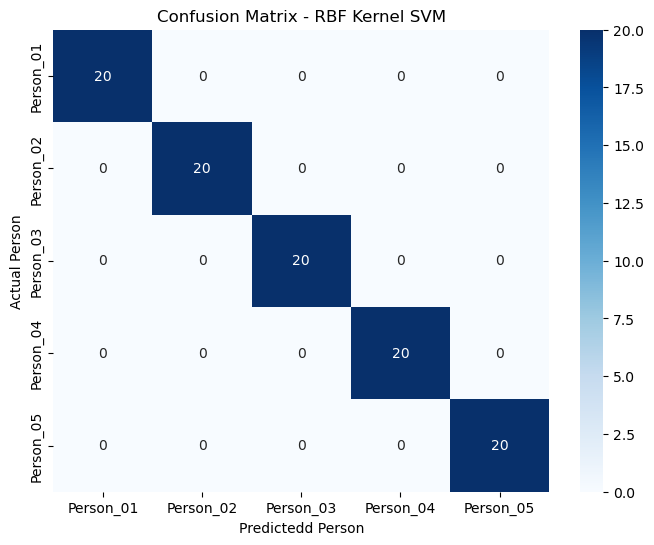

In [50]:
# Step No 17 : Confusion Matrix Visualization 
# Create figure 
plt.figure(
    figsize=(8,6)
)
# Create heatmap 
sns.heatmap(
    cm , 
    annot=True,
    fmt = "d",
    cmap = "Blues",
    xticklabels=np.unique(y),
    yticklabels=np.unique(y)
)

# Set title 
plt.title(
    "Confusion Matrix - RBF Kernel SVM"
)
# Set x-axis label 
plt.xlabel(
    "Predictedd Person"
)

# Set y-axis label 
plt.ylabel(
    "Actual Person"
)
# Display plot 
plt.show()

In [51]:
# Step No 18 : User Input - New Face Image

# Define exact image path
image_path = r"C:\Users\sagar\Desktop\Machine Learning Models Practice\Machine_Learning_All_Models\07_SVM_Alogorithm\RBF Kernel\Face_Recognition_RBF_SVM_Dataset\Person_01\face_002.png"

# Display image path
print("\nImage Path :")
print(image_path)

# Check whether image exists
print("\nImage Exists :")
print(os.path.exists(image_path))


Image Path :
C:\Users\sagar\Desktop\Machine Learning Models Practice\Machine_Learning_All_Models\07_SVM_Alogorithm\RBF Kernel\Face_Recognition_RBF_SVM_Dataset\Person_01\face_002.png

Image Exists :
True


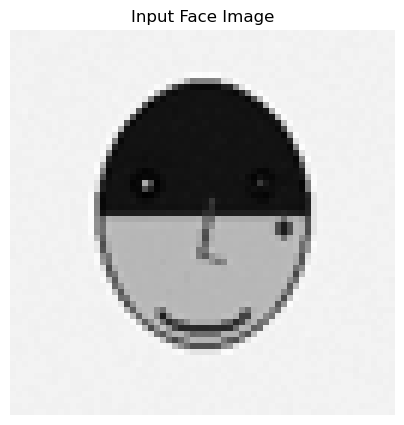


Recognized Person :  Person_01


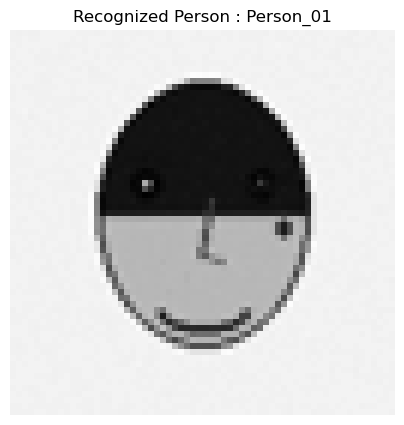

In [52]:
# Step No 19 : Check Image Path

# Check whether image exists
if not os.path.exists(image_path):

    print(
        "\nImage not found."
        "\nPlease check the image path."
    )

else:

    # Step No 20 : Load New Face Image

    # Open new image
    image = Image.open(
        image_path
    )

    # Convert image into grayscale
    image = image.convert(
        "L"
    )

    # Resize image to 64 X 64
    image = image.resize(
        (64, 64)
    )

    # Display new input image
    plt.figure(
        figsize=(5, 5)
    )

    plt.imshow(
        image,
        cmap="gray"
    )

    plt.title(
        "Input Face Image"
    )

    plt.axis("off")

    plt.show()


    # Step No 21 : Convert Image into NumPy Array

    # Convert image into NumPy array
    image_array = np.array(
        image
    )

    # Normalize pixel values
    image_array = image_array / 255.0

    # Flatten image
    image_array = image_array.flatten()

    # Convert into 2D format
    image_array = image_array.reshape(
        1,
        -1
    )


    # Step No 22 : Scale New Image

    # Scale new image using fitted scaler
    image_scaled = scaler.transform(
        image_array
    )


    # Step No 23 : Predict Person

    # Predict person
    result = model.predict(
        image_scaled
    )


    # Step No 24 : Display Final Result

    print(
        "\nRecognized Person : ",
        result[0]
    )


    # Display final image with prediction
    plt.figure(
        figsize=(5, 5)
    )

    plt.imshow(
        image,
        cmap="gray"
    )

    plt.title(
        "Recognized Person : " + result[0]
    )

    plt.axis("off")

    plt.show()